# Preference on the stimulus axis: one row per decoder

The stacked panels from `notebooks/20260810_visualize_pref_on_choice_axis.ipynb`, written out as
svg. Three decoders, one per row of every figure, all on the same y axis:

| row | mode | trials, units | path |
| --- | --- | --- | --- |
| stim | `choice` | `Response Correct`, `BeliefPartition High Not X`, all units | `/data/patrick_res/choice_reward` |
| preference | `pref` | `Response Correct`, `Choice Chose`, `pref_99th_window_filter_drift` | `/data/patrick_res/belief_partitions` |
| pref on stim ax | `pref_on_choice_Response_Correct_BeliefPartition_High_Not_X` | same as preference | `/data/patrick_res/choice_axis_projection_accs` |

Row 1 is the axis itself: Chose X vs. Not Chose X fit on the full population, over the trials
`AXIS_BEH_FILTERS` names -- with the default filters those are the correct trials where X was *not*
preferred, so the contrast is the A vs. B stimulus step and the axis is a stimulus axis, which is
why the row is labelled "stim". Row 2 is preference decoding, High X vs. High Not X, fit on its own
conditions. Row 3 is row 2's conditions read out along row 1's axis, its direction fixed and only a
threshold refit -- computed by
`scripts/pseudo_decoding/belief_partitions/decode_pref_on_choice_axis.py`, which reuses the
preference run's units, trials, splits and pseudo-population generation, so rows 2 and 3 are
directly comparable.

Rows 1 and 2 are **not** on the same trials or units, so the comparison to read is each row against
its own session-permute shuffle, not row 1's height against row 2's. Every panel carries one row of
significance bars beneath its traces: the one-sided permutation test of that series against its own
shuffle at each timepoint, thicker bars for smaller p (p < 0.05 / 0.01 / 0.001,
`visualization_utils.SIG_LEVELS`).

Whole population first, then the 6 regions of interest, labelled by the abbreviations in
`visualization_utils.REGION_TO_ABBREV`. Figures are written as svg to
`/data/patrick_res/figures/wcst_paper/belief_stim_projections/`.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import argparse
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
import utils.stats_utils as stats_utils
from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import *
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io
from scripts.pseudo_decoding.belief_partitions.decode_pref_on_choice_axis import get_proj_mode

plt.rcParams.update({"font.size": 16})

FIG_PATH = "/data/patrick_res/figures/wcst_paper/belief_stim_projections"


## What is read

`AXIS_BEH_FILTERS` picks which set of runs the whole notebook reads -- both the projection in row 3
and the `choice` run in row 1, so row 1 is always the axis row 3 was projected onto. All three
options below are on disk, so flipping this reproduces the earlier versions of the figure. The file
names do not record it, so re-running with a different axis overwrites the svgs already there.


In [2]:
# Trials the axis was fit on:
#   {}                        -> the original all-trials choice axis, mode pref_on_choice
#   {"Response": "Correct"}   -> the correct-only choice re-runs, mode pref_on_choice_Response_Correct
#   {"Response": "Correct", "BeliefPartition": "High Not X"} -> the A-vs-B stimulus axis of the A/B/C design, mode pref_on_choice_Response_Correct_BeliefPartition_High_Not_X
AXIS_BEH_FILTERS = {"Response": "Correct", "BeliefPartition": "High Not X"}
PROJ_MODE = get_proj_mode(AXIS_BEH_FILTERS)

MODE_TO_BASE_PATH = {
    "pref": "/data/patrick_res/belief_partitions",
    PROJ_MODE: "/data/patrick_res/choice_axis_projection_accs",
    # choice decoding fit on all units, the runs decode_pref_on_choice_axis.py takes its axis from
    "choice": "/data/patrick_res/choice_reward",
}

# Trial events drawn, one column per event in every figure. Set to
# ["StimOnset", "FeedbackOnsetLong"] to bring the stimulus aligned column back.
TRIAL_EVENTS = ["FeedbackOnsetLong"]

# one mode per row of the figure, top to bottom
ROW_MODES = ["choice", "pref", PROJ_MODE]

# Display names for the legends. The `choice` mode is labelled "stim", since with the current
# AXIS_BEH_FILTERS the axis it provides is the A vs. B stimulus axis, not a choice axis.
SERIES_NAMES = {
    "pref": "preference",
    "pref_shuffle": "preference shuffle",
    PROJ_MODE: "pref on stim ax",
    f"{PROJ_MODE}_shuffle": "pref on stim ax shuffle",
    "choice": "stim",
    "choice_shuffle": "stim shuffle",
}
SERIES_TO_COLOR = {
    "preference": "tab:blue",
    "preference shuffle": "#aec7e8",
    "pref on stim ax": "tab:purple",
    "pref on stim ax shuffle": "#c5b0d5",
    "stim": "tab:orange",
    "stim shuffle": "#ffbb78",
}

# whole population, then the 6 regions of interest, labelled by their abbreviations
POPULATIONS = [(None, None, "whole population")] + [
    ("structure_level2_cleaned", region, visualization_utils.REGION_TO_ABBREV[region])
    for region in REGIONS_OF_INTEREST
]


def get_args(mode, region_level, regions, trial_event):
    """
    Configs for one mode's run: the trials and units it ran on, and the path it's stored under
    """
    args = argparse.Namespace(**BeliefPartitionConfigs()._asdict())
    args.subject = "both"
    args.mode = mode
    if mode == "choice":
        # the all units choice runs use no subpopulation, and only the trials AXIS_BEH_FILTERS
        # names -- matching what decode_pref_on_choice_axis.load_choice_axes reads for the same
        # filters, see slurm_launch_choice_all_units.sh
        args.beh_filters = AXIS_BEH_FILTERS
        args.sig_unit_level = None
    else:
        args.beh_filters = {"Response": "Correct", "Choice": "Chose"}
        args.sig_unit_level = "pref_99th_window_filter_drift"
    args.region_level = region_level
    args.regions = regions
    args.trial_event = trial_event
    args.base_output_path = MODE_TO_BASE_PATH[mode]
    return args


def read_modes(region_level, regions, trial_event, modes=ROW_MODES):
    """
    Reads each mode's accuracies, with their shuffles, into one frame
    """
    res = []
    for mode in modes:
        args = get_args(mode, region_level, regions, trial_event)
        res.append(belief_partitions_io.read_results(args, FEATURES))
    res = pd.concat(res)
    res["series"] = res["mode"].map(SERIES_NAMES)
    res["trial_event"] = trial_event
    return res


CHOICE_PVALS = {}


def get_choice_pvals(region_level, regions, trial_event, res=None):
    """
    Choice's per-timepoint p value against its own shuffle, computed here and cached.

    The all-unit choice runs have no p values on disk: compute_p_vals_for_decoders.py only covers
    the choice_99th_window_filter_drift subpop, whose dirs are the *_units ones. This is the same
    one-sided permutation test it would have written, run over the results already in memory.
    """
    key = (regions, trial_event)
    if key not in CHOICE_PVALS:
        args = get_args("choice", region_level, regions, trial_event)
        if res is None:
            res = belief_partitions_io.read_results(args, FEATURES)
        else:
            res = res[res["mode"].isin(["choice", "choice_shuffle"])].copy()
        CHOICE_PVALS[key] = stats_utils.compute_p_for_decoding_by_time(res, args)
    return CHOICE_PVALS[key]


def read_pvals(region_level, regions, trial_event, modes=ROW_MODES, res=None):
    """
    Reads each mode's per-timepoint p value against its own shuffle, keyed by series name.
    All are the same one-sided permutation test (stats_utils.compute_p_for_decoding_by_time),
    written by p_val_computations/compute_p_vals_for_decoders.py for preference and
    p_val_computations/compute_p_vals_for_pref_on_choice.py for the projection, computed on the
    fly for choice. `res` lets choice reuse an already read frame.
    """
    p_vals = {}
    for mode in modes:
        if mode == "choice":
            p_vals[SERIES_NAMES[mode]] = get_choice_pvals(region_level, regions, trial_event, res)
            continue
        args = get_args(mode, region_level, regions, trial_event)
        dir = belief_partitions_io.get_dir_name(args, make_dir=False)
        p_vals[SERIES_NAMES[mode]] = pd.read_pickle(os.path.join(dir, f"{mode}_pvals.pickle"))
    return p_vals


## The figure

One row per mode, one column per trial event, every panel sharing a y axis so the rows can be read
against each other. Each panel holds that mode's trace and its shuffle and nothing else, with a row
of significance bars underneath.

`save_fig` writes the svg with `bbox_inches="tight"`: the figure reserves a fixed 4in of width for
the y axis and the legends sitting outside the last column, and `tight_layout` does not pull that
margin back in, so without the tight bbox the file carries whatever slice of it the legends do not
use as blank canvas.


In [3]:
def format_event_axis(ax, trial_event, with_xlabel=True):
    """
    Event markers, ticks and x label for one trial event's column of axes
    """
    ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)
    if trial_event == "StimOnset":
        ax.axvline(-.5, color="grey", linestyle="dotted", linewidth=3)
        ticks = [-1, -.5, 0, .5, 1]
        label = "Time to stimuli appear (s)"
    else:
        ax.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
        ticks = [-1.5, -1, -.5, 0, .5, 1, 1.5]
        label = "Time to feedback (s)"
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_xlabel(label if with_xlabel else None)


def plot_stacked_accs(region_level, regions, title=None, trial_events=None):
    """
    One row per mode rather than overlaying them: choice on top, preference, then preference
    projected onto the choice axis. Columns are the trial events, TRIAL_EVENTS by default, and
    every panel shares a y axis so the rows can be read against each other.
    """
    trial_events = TRIAL_EVENTS if trial_events is None else trial_events
    res = {
        trial_event: read_modes(region_level, regions, trial_event, modes=ROW_MODES)
        for trial_event in trial_events
    }

    fig, axs = plt.subplots(
        len(ROW_MODES), len(trial_events),
        # 5.5in per column plus a fixed 4in for the y axis and the legends outside the last
        # column, which tight_layout otherwise takes out of the panels themselves
        figsize=(4 + 5.5 * len(trial_events), 3 * len(ROW_MODES)),
        sharey=True, sharex="col", squeeze=False,
        width_ratios=[res[trial_event].Time.nunique() for trial_event in trial_events]
    )
    for row, mode in enumerate(ROW_MODES):
        # the mode's own trace and its shuffle, nothing else in the panel
        series = [SERIES_NAMES[mode], SERIES_NAMES[f"{mode}_shuffle"]]
        for col, trial_event in enumerate(trial_events):
            ax = axs[row, col]
            sns.lineplot(
                res[trial_event][res[trial_event].series.isin(series)],
                x="Time", y="Accuracy", hue="series", hue_order=series,
                palette=SERIES_TO_COLOR, linewidth=3, ax=ax, errorbar="se"
            )
            ax.axhline(y=0.5, linestyle="dotted", color="black")
            format_event_axis(ax, trial_event, with_xlabel=row == len(ROW_MODES) - 1)

    # one row of significance bars per panel, that mode against its own shuffle, colored to
    # match the trace. Read the shared limits before any bar can rescale the axes.
    bottom, top = axs[0, 0].get_ylim()
    spacing = 0.08 * (top - bottom)
    for row, mode in enumerate(ROW_MODES):
        for col, trial_event in enumerate(trial_events):
            p_vals = read_pvals(
                region_level, regions, trial_event, modes=[mode], res=res[trial_event]
            )
            visualization_utils.plot_sig_bars(
                p_vals[SERIES_NAMES[mode]], bottom - spacing, axs[row, col],
                color=SERIES_TO_COLOR[SERIES_NAMES[mode]]
            )
    # shared y, so these set every panel: room for the bars without rescaling the traces, and
    # ticks kept on the traces, since an accuracy tick in the bar strip reads as data
    axs[0, 0].set_ylim(bottom - 1.5 * spacing, top)
    axs[0, 0].set_yticks([tick for tick in axs[0, 0].get_yticks() if bottom <= tick <= top])

    visualization_utils.format_plot(axs)
    for row in range(len(ROW_MODES)):
        axs[row, 0].set_ylabel("Accuracy")
        for col in range(1, len(trial_events)):
            axs[row, col].set_ylabel(None)
        for col in range(len(trial_events) - 1):
            axs[row, col].get_legend().remove()
        # per row, since each row names its own pair of series
        legend = axs[row, -1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
        for line in legend.get_lines():
            line.set_linewidth(6)
    if title:
        axs[0, 0].set_title(title, loc="left")
    fig.tight_layout()
    return fig, axs, pd.concat(res.values())


def save_fig(fig, name):
    """
    Writes one population's figure out, named by the population as POPULATIONS labels it
    """
    os.makedirs(FIG_PATH, exist_ok=True)
    path = os.path.join(FIG_PATH, f"stacked_{name.replace(' ', '_')}.svg")
    fig.savefig(path, bbox_inches="tight")
    print(path)


## Whole population, stacked

100%|██████████| 33/33 [00:05<00:00,  6.27it/s]


/data/patrick_res/figures/wcst_paper/belief_stim_projections/stacked_whole_population.svg


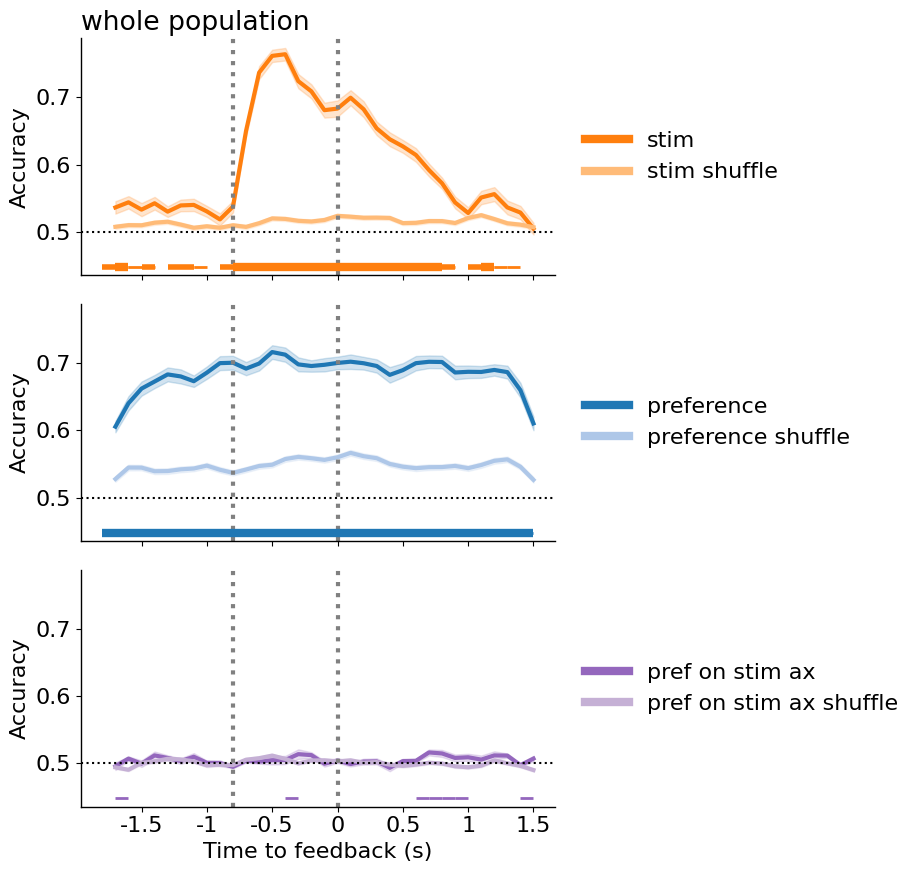

In [4]:
fig, _, whole_pop_stacked_res = plot_stacked_accs(None, None, title="whole population")
save_fig(fig, "whole population")


## Regions of interest, stacked

100%|██████████| 33/33 [00:00<00:00, 43.94it/s]


/data/patrick_res/figures/wcst_paper/belief_stim_projections/stacked_AMY.svg


100%|██████████| 33/33 [00:00<00:00, 43.97it/s]


/data/patrick_res/figures/wcst_paper/belief_stim_projections/stacked_DSTR.svg


100%|██████████| 33/33 [00:00<00:00, 44.04it/s]


...

/data/patrick_res/figures/wcst_paper/belief_stim_projections/stacked_HC.svg


100%|██████████| 33/33 [00:00<00:00, 44.05it/s]


/data/patrick_res/figures/wcst_paper/belief_stim_projections/stacked_LPFC.svg


100%|██████████| 33/33 [00:00<00:00, 44.16it/s]


/data/patrick_res/figures/wcst_paper/belief_stim_projections/stacked_ACC.svg


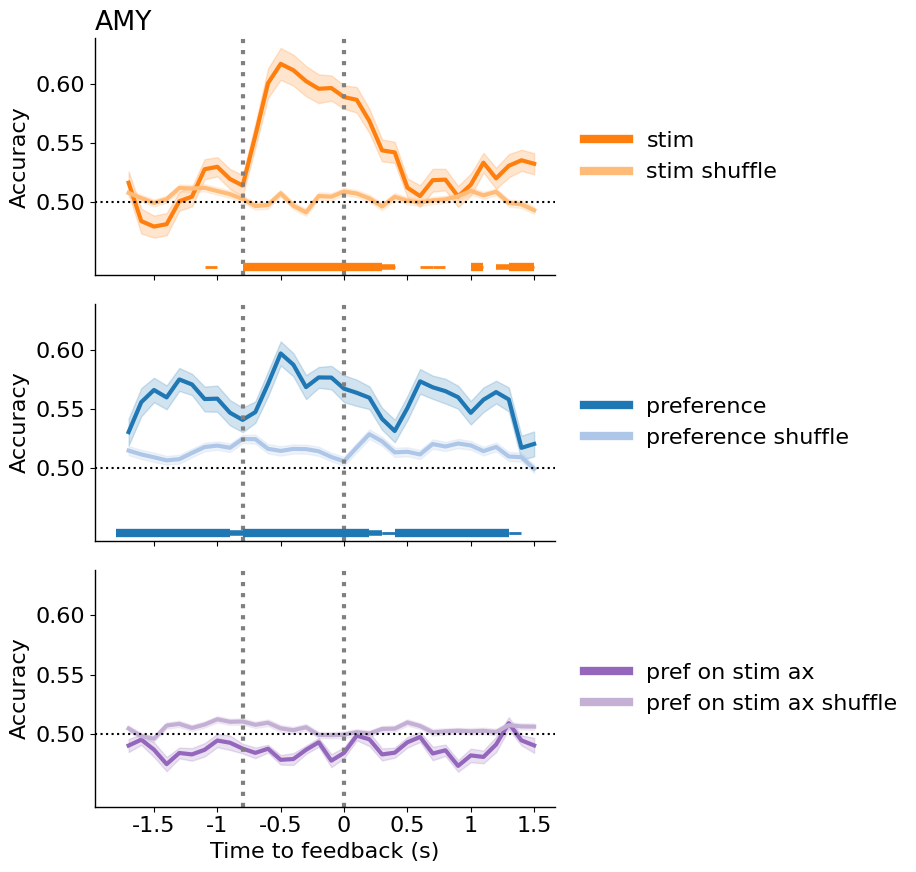

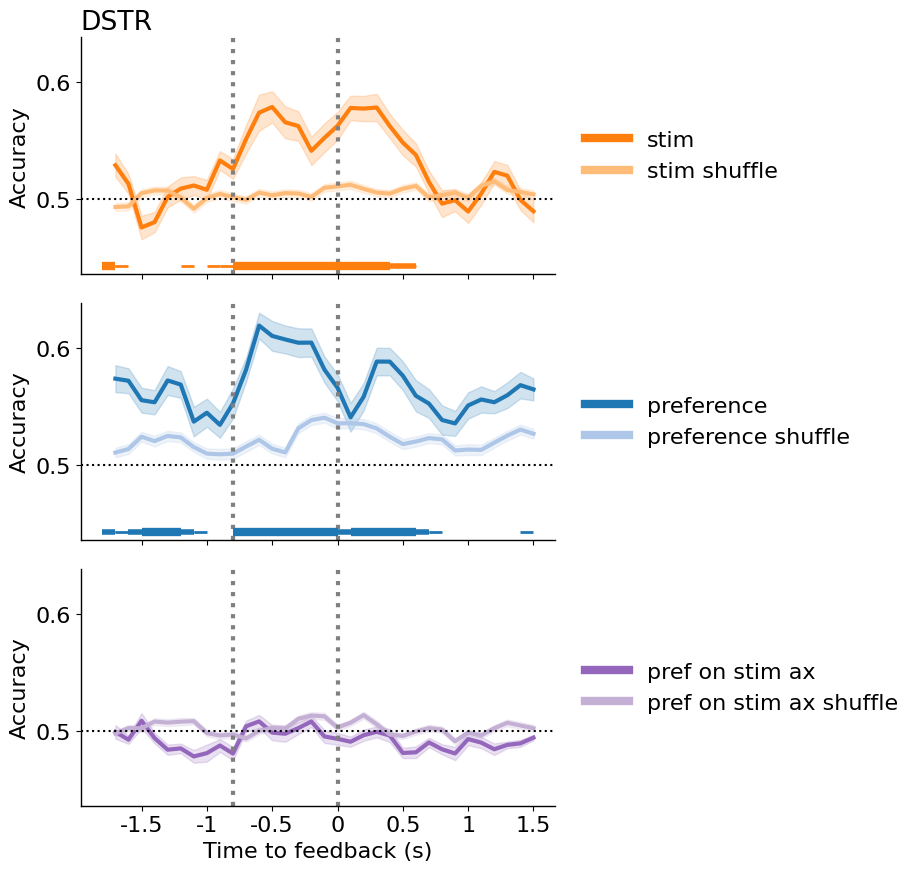

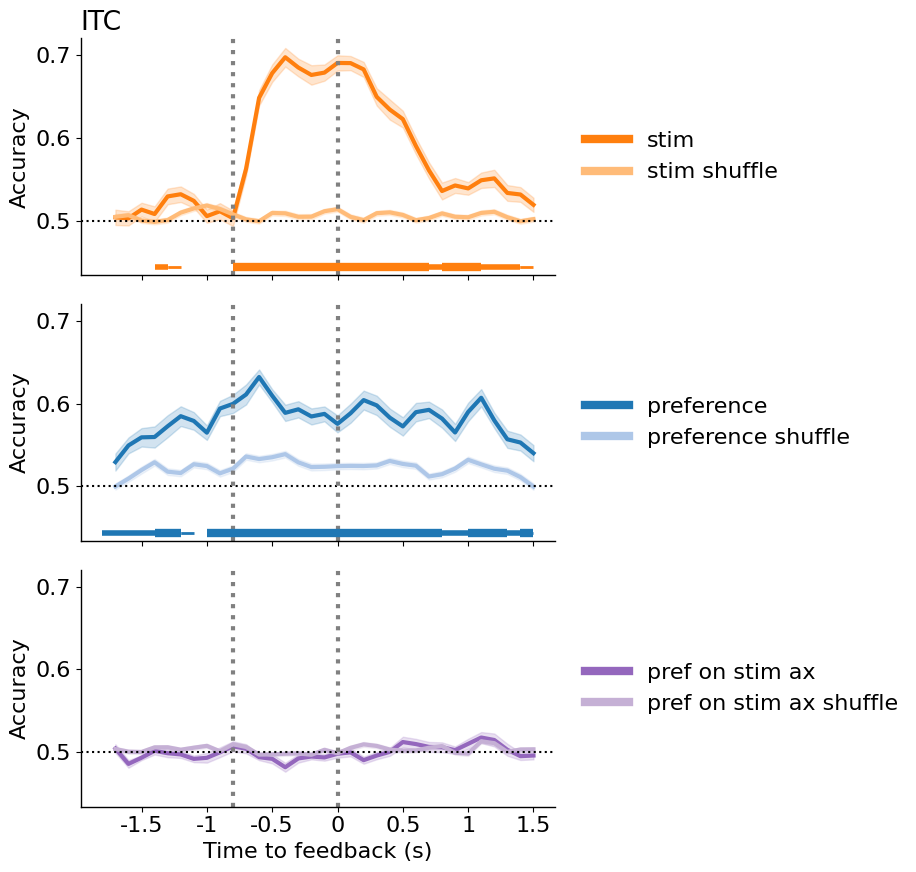

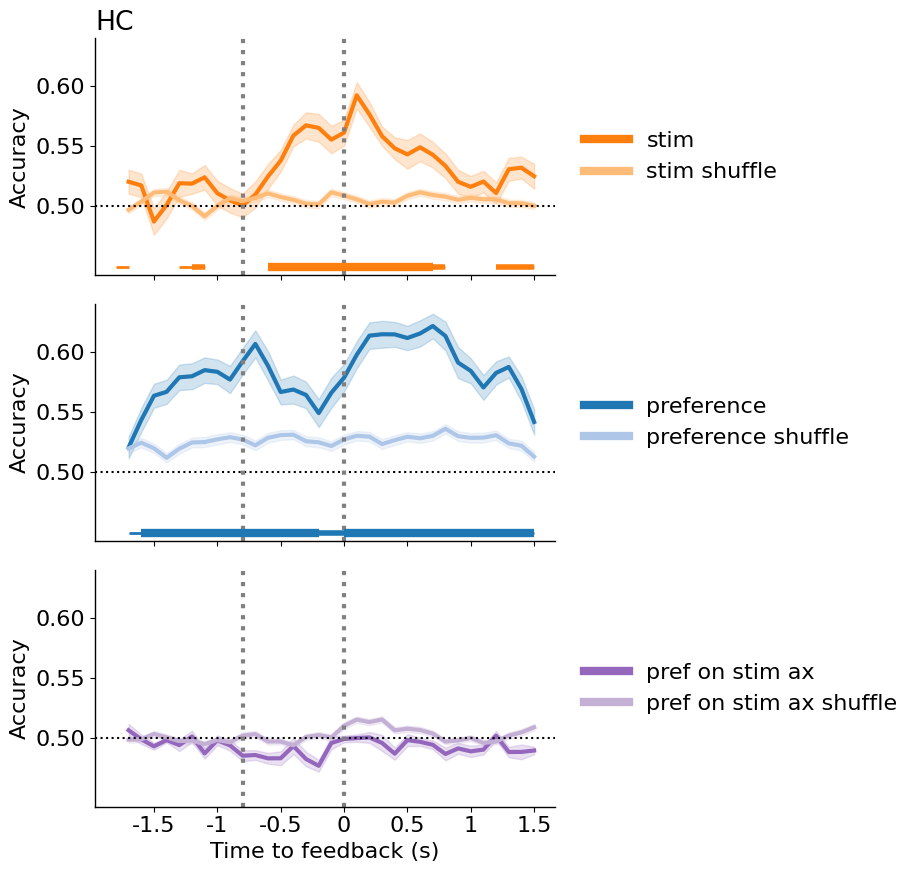

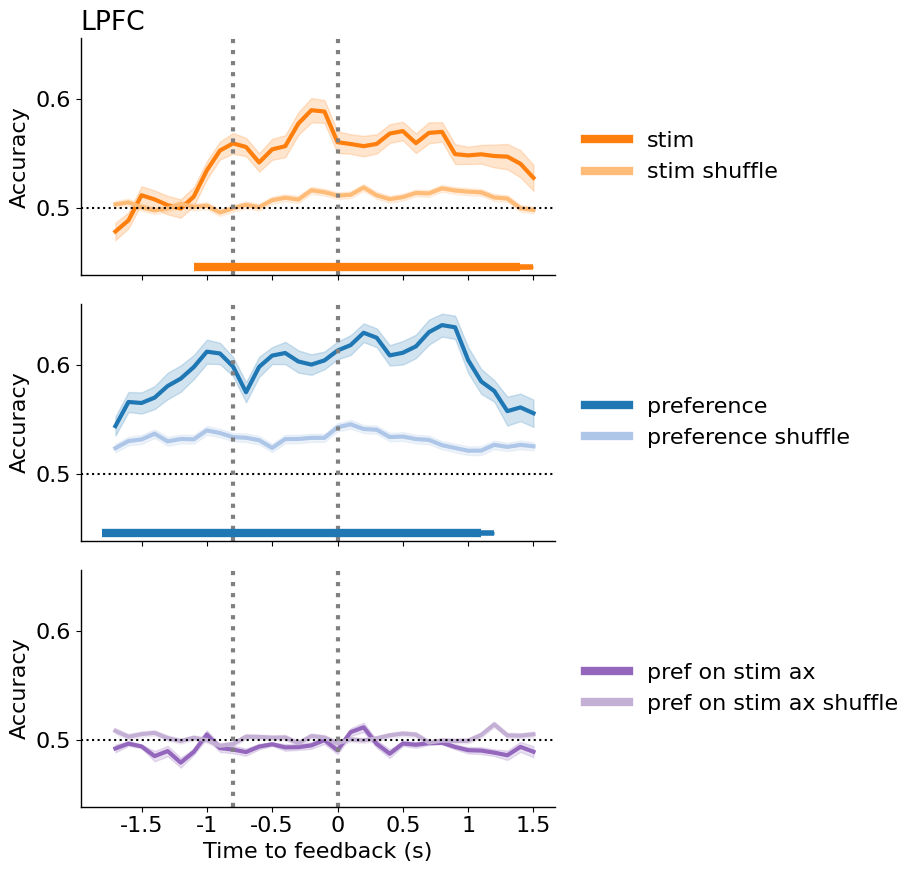

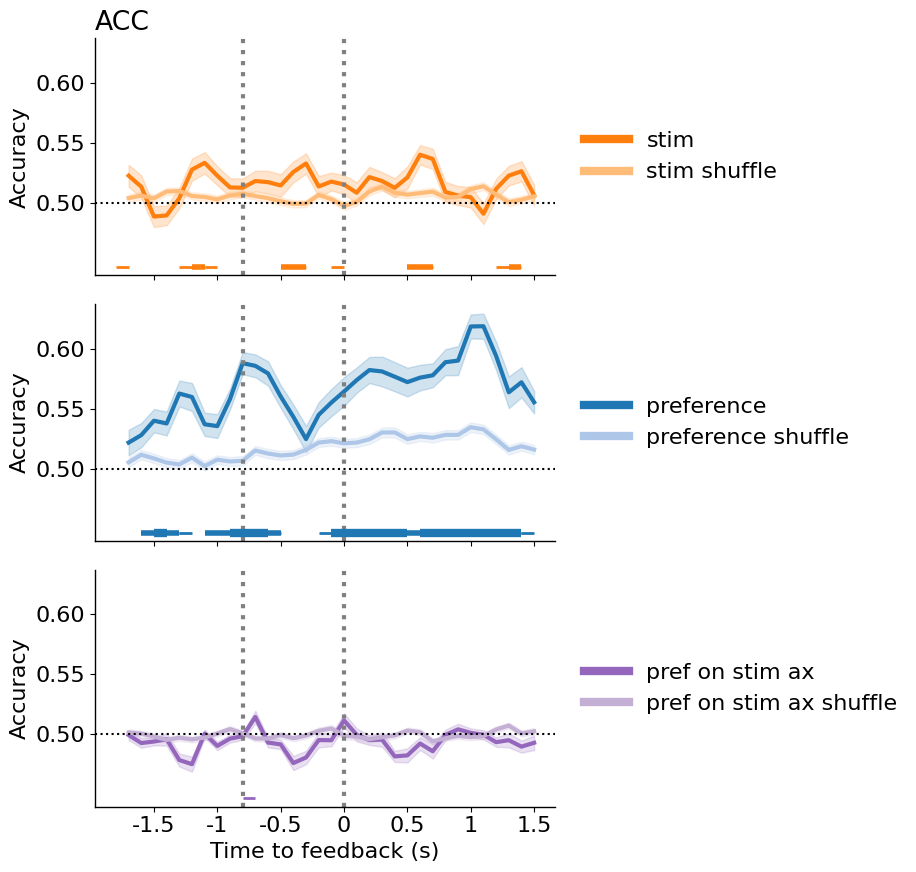

In [5]:
all_stacked_res = [whole_pop_stacked_res.assign(population="whole population")]
for region_level, regions, name in POPULATIONS[1:]:
    fig, _, res = plot_stacked_accs(region_level, regions, title=name)
    save_fig(fig, name)
    all_stacked_res.append(res.assign(population=name))
all_stacked_res = pd.concat(all_stacked_res)


## Regions of interest, one figure

The 6 per-region figures above as panels of one 2 x 3 grid, reusing the results they already read.
Every axis in the figure shares one y axis, so regions can be read against each other as well as
rows, and one legend on the right names all six series.

/data/patrick_res/figures/wcst_paper/belief_stim_projections/stacked_regions_grid.svg


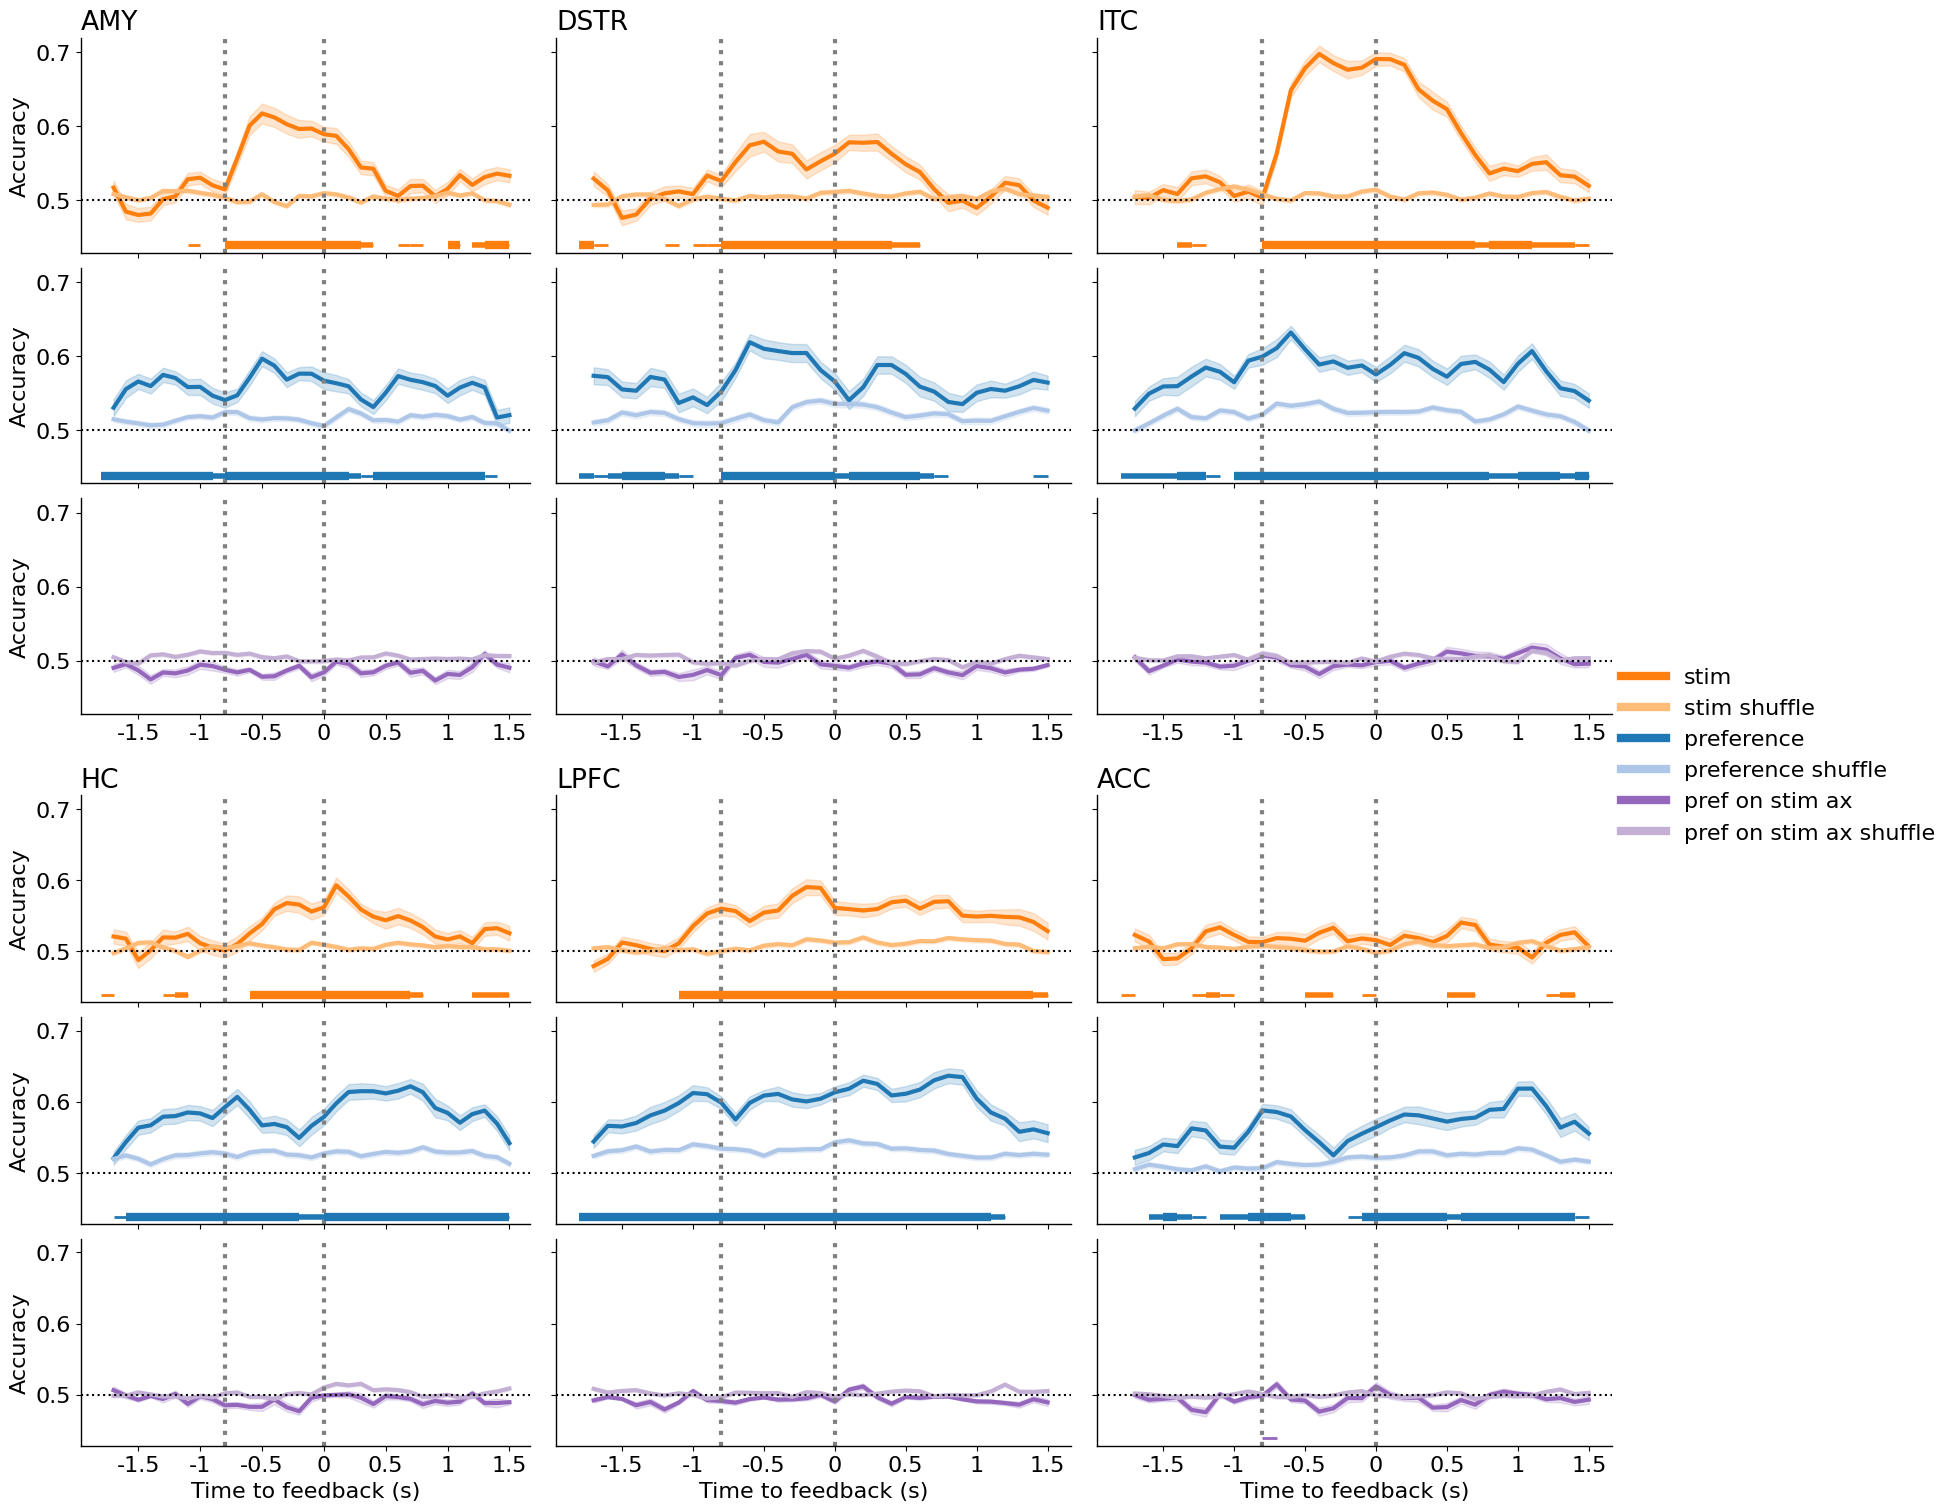

In [7]:
def plot_stacked_accs_grid(res, populations, trial_events=None, n_cols=3):
    """
    plot_stacked_accs for several populations in one figure: each population's stack of rows is
    one panel of an n_cols wide grid, every axis in the figure shares one y range, and a single
    legend names all the series. `res` is the frame the per-population figures already read, with
    a population column, so nothing is read again.
    """
    trial_events = TRIAL_EVENTS if trial_events is None else trial_events
    n_rows = int(np.ceil(len(populations) / n_cols))
    fig = plt.figure(
        figsize=(3 + 5.5 * len(trial_events) * n_cols, 2.5 * len(ROW_MODES) * n_rows),
        layout="constrained",
    )
    subfigs = fig.subfigures(n_rows, n_cols, squeeze=False)
    # every population's axes, shape (population, mode, trial event)
    all_axs = np.array([
        subfig.subplots(
            len(ROW_MODES), len(trial_events), sharex="col", squeeze=False,
            width_ratios=[res[res.trial_event == trial_event].Time.nunique() for trial_event in trial_events]
        )
        for subfig, _ in zip(subfigs.flat, populations)
    ])

    for pop_idx, (region_level, regions, name) in enumerate(populations):
        pop_res = res[res.population == name]
        is_bottom = pop_idx // n_cols == n_rows - 1
        for row, mode in enumerate(ROW_MODES):
            series = [SERIES_NAMES[mode], SERIES_NAMES[f"{mode}_shuffle"]]
            for col, trial_event in enumerate(trial_events):
                ax = all_axs[pop_idx, row, col]
                sns.lineplot(
                    pop_res[(pop_res.trial_event == trial_event) & pop_res.series.isin(series)],
                    x="Time", y="Accuracy", hue="series", hue_order=series,
                    palette=SERIES_TO_COLOR, linewidth=3, ax=ax, errorbar="se"
                )
                ax.axhline(y=0.5, linestyle="dotted", color="black")
                format_event_axis(ax, trial_event, with_xlabel=is_bottom and row == len(ROW_MODES) - 1)
        all_axs[pop_idx, 0, 0].set_title(name, loc="left")

    # one legend for the whole figure, taking each mode's pair of series from the first population
    handles, labels = [], []
    for row in range(len(ROW_MODES)):
        row_handles, row_labels = all_axs[0, row, 0].get_legend_handles_labels()
        handles += row_handles
        labels += row_labels
    for ax in all_axs.flat:
        ax.get_legend().remove()
    legend = fig.legend(handles, labels, loc="outside right center", frameon=False)
    for line in legend.get_lines():
        line.set_linewidth(6)

    # one y range for every axis, set by hand rather than with ax.sharey: axes in different
    # subfigures count as different figures, so sharing makes every limit change on one axis
    # redraw the whole figure once per sibling (Axis._set_lim -> draw_idle), which inline is a
    # full constrained layout solve each time
    ylims = np.array([ax.get_ylim() for ax in all_axs.flat])
    bottom, top = ylims[:, 0].min(), ylims[:, 1].max()
    # significance bars as in plot_stacked_accs, placed off that range
    spacing = 0.08 * (top - bottom)
    for pop_idx, (region_level, regions, name) in enumerate(populations):
        pop_res = res[res.population == name]
        for row, mode in enumerate(ROW_MODES):
            for col, trial_event in enumerate(trial_events):
                p_vals = read_pvals(
                    region_level, regions, trial_event, modes=[mode],
                    res=pop_res[pop_res.trial_event == trial_event]
                )
                visualization_utils.plot_sig_bars(
                    p_vals[SERIES_NAMES[mode]], bottom - spacing, all_axs[pop_idx, row, col],
                    color=SERIES_TO_COLOR[SERIES_NAMES[mode]]
                )
    all_axs.flat[0].set_ylim(bottom - 1.5 * spacing, top)
    yticks = [tick for tick in all_axs.flat[0].get_yticks() if bottom <= tick <= top]
    for ax in all_axs.flat:
        ax.set_ylim(bottom - 1.5 * spacing, top)
        ax.set_yticks(yticks)

    visualization_utils.format_plot(all_axs)
    # y labels and tick labels only down the left edge of the grid
    for pop_idx in range(len(populations)):
        for row in range(len(ROW_MODES)):
            for col in range(len(trial_events)):
                ax = all_axs[pop_idx, row, col]
                if pop_idx % n_cols == 0 and col == 0:
                    ax.set_ylabel("Accuracy")
                else:
                    ax.set_ylabel(None)
                    ax.tick_params(labelleft=False)
    return fig, all_axs


fig, _ = plot_stacked_accs_grid(all_stacked_res, POPULATIONS[1:])
save_fig(fig, "regions grid")

## Summary

Mean accuracy over all time bins, features and runs, alongside each series' distance above its own
shuffle. `frac` is how much of preference's separation over its own shuffle is recovered on the
stimulus axis. `stim gap` is the same distance for the all-unit `choice` decoding the axis comes
from, on its own trials and units, so it is context for how strong that axis is rather than
something preference is measured against.


In [6]:
def mean_by_series(res):
    return res.groupby(["population", "trial_event", "series"]).Accuracy.mean().unstack("series")


summary = mean_by_series(all_stacked_res)
summary["pref gap"] = summary["preference"] - summary["preference shuffle"]
summary["proj gap"] = summary["pref on stim ax"] - summary["pref on stim ax shuffle"]
summary["frac"] = summary["proj gap"] / summary["pref gap"]
summary["stim gap"] = summary["stim"] - summary["stim shuffle"]
summary = summary.reindex(
    [name for _, _, name in POPULATIONS], level="population"
).reindex(TRIAL_EVENTS, level="trial_event")
summary.round(3)


,series,pref on stim ax,pref on stim ax shuffle,preference,preference shuffle,stim,stim shuffle,pref gap,proj gap,frac,stim gap
population,trial_event,,,,,,,,,,
whole population,FeedbackOnsetLong,0.505,0.500,0.685,0.548,0.603,0.514,0.137,0.004,0.032,0.088
AMY,FeedbackOnsetLong,0.488,0.505,0.559,0.515,0.539,0.504,0.043,-0.017,-0.391,0.036
DSTR,FeedbackOnsetLong,0.492,0.502,0.567,0.522,0.530,0.505,0.046,-0.011,-0.230,0.025
ITC,FeedbackOnsetLong,0.499,0.503,0.581,0.522,0.581,0.506,0.059,-0.004,-0.065,0.075
HC,FeedbackOnsetLong,0.492,0.502,0.582,0.526,0.533,0.505,0.056,-0.009,-0.167,0.028
LPFC,FeedbackOnsetLong,0.493,0.502,0.597,0.532,0.546,0.508,0.065,-0.009,-0.132,0.038
ACC,FeedbackOnsetLong,0.494,0.500,0.566,0.518,0.516,0.506,0.048,-0.006,-0.122,0.010
